In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import io
import zipfile
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


def download_file(url: str, dest: Path, timeout: int = 45):
    if dest.exists():
        return dest
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    dest.write_bytes(r.content)
    return dest


def print_source(name: str, mode: str):
    print(f"[{name}] data source: {mode}")

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_diabetes


def load_diabetes_data():
    local_csv = DATA_DIR / "diabetes.csv"
    if local_csv.exists():
        df = pd.read_csv(local_csv)
        print_source("Diabetes", "local csv")
        return df

    try:
        url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
        df = pd.read_csv(url)
        print_source("Diabetes", "downloaded PIMA csv mirror")
        return df
    except Exception as e:
        print("Download failed, using sklearn fallback:", e)

    # sklearn load_diabetes is regression; binarize target at median for classification fallback.
    ds = load_diabetes(as_frame=True)
    df = ds.frame.copy()
    df["Outcome"] = (df["target"] > df["target"].median()).astype(int)
    df = df.drop(columns=["target"])
    print_source("Diabetes", "sklearn fallback (binarized)")
    return df


df = load_diabetes_data()
print("Shape:", df.shape)
df.head()

[Diabetes] data source: downloaded PIMA csv mirror
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
target_col = next((c for c in ["Outcome", "target", "class", "diabetes"] if c in df.columns), None)
if target_col is None:
    raise ValueError(f"Could not identify target column from: {list(df.columns)}")

X = df.drop(columns=[target_col]).copy()
y = pd.to_numeric(df[target_col], errors="coerce").fillna(0).astype(int)

for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors="coerce")

for c in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    if c in X.columns:
        X[c] = X[c].replace(0, np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42)),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

           0     0.8242    0.7500    0.7853       100
           1     0.6032    0.7037    0.6496        54

    accuracy                         0.7338       154
   macro avg     0.7137    0.7269    0.7175       154
weighted avg     0.7467    0.7338    0.7377       154

ROC-AUC: 0.8126


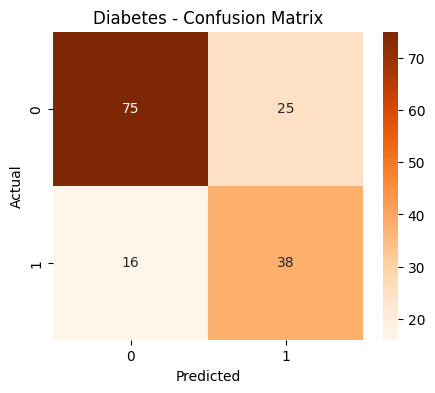

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Diabetes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()